# Étude Approfondie : Infrastructures de Recharge (IRVE)

## 1. Introduction et Objectifs

Ce notebook est dédié à l'analyse des données IRVE (Infrastructures de Recharge pour Véhicules Électriques). Contrairement aux données INSEE, ces données sont "sales" et nécessitent un traitement important avant de pouvoir être agrégées à l'échelle communale.

L'objectif final de ce notebook est de construire un jeu de données agrégé par code géographique à partir de la base nationale des bornes de recharge électrique (IRVE), afin d'expliquer ou prédire le taux de véhicules électriques local.

## 2. Initialisation des données

Ici, chaque ligne correspond à une borne / point de recharge déclaré. L'objectif final étant une modélisation territoriale, chaque borne doit être rattachée à une zone géographique.

Pour mener cette étude, nous devons d'abord garantir l'intégrité géographique de la base IRVE. Cette étape technique permet de compléter les codes INSEE manquants via un géocodage spatial (coordonnées GPS) afin d'assurer une base de données exhaustive pour l'analyse.

In [1]:
import pandas as pd
from src.utils import (
    creer_gdf_irve,
    joindre_communes,
    ajouter_codes_geo
)
from src.loading import load_irve_data, charger_communes
from src.cleaning import (
    nettoyer_code_insee
)

# 1. Chargement
url_irve ="https://www.data.gouv.fr/api/1/datasets/r/eb76d20a-8501-400e-b336-d85724de5435"
df_irve = load_irve_data(url_irve)

# 2. Préparation technique (Codes Géo)
df_irve["code_insee_commune"] = df_irve["code_insee_commune"].apply(nettoyer_code_insee)
gdf_irve = creer_gdf_irve(df_irve, "consolidated_longitude", "consolidated_latitude")
gdf_communes = charger_communes()
gdf_result = joindre_communes(gdf_irve, gdf_communes)
df_irve = ajouter_codes_geo(df_irve, gdf_result)

print(f"Base chargée et géocodée : {len(df_irve)} points de charge prêts pour l'analyse.")
df_irve.sample(5)

/home/onyxia/work/projet_python_pour_la_data_science/src/loading.py:10: DtypeWarning: Columns (12,18,19,20,21,22,24,25,29,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_or_url)
There was an error while reading the file from the URL: https://minio.lab.sspcloud.fr/projet-cartiflette/production/provider=IGN/dataset_family=ADMINEXPRESS/source=EXPRESS-COG-CARTO-TERRITOIRE/year=2022/administrative_level=COMMUNE/crs=4326/DEPARTEMENT=20/vectorfile_format=geojson/territory=metropole/simplification=0/raw.geojson
Error message: '/vsimem/pyogrio_30a996b5a8b344cfa43de0747649d9e6' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.


Base chargée et géocodée : 192863 points de charge prêts pour l'analyse.


,nom_amenageur,siren_amenageur,contact_amenageur,nom_operateur,contact_operateur,telephone_operateur,nom_enseigne,id_station_itinerance,id_station_local,nom_station,...,datagouv_organization_or_owner,created_at,consolidated_longitude,consolidated_latitude,consolidated_code_postal,consolidated_commune,consolidated_is_lon_lat_correct,consolidated_is_code_insee_verified,consolidated_is_code_insee_modified,code_geo_total
90964,Mobilize Power Solutions,881248165.0,operations@mobilize-ps.fr,Mobilize Power Solutions,support@mobilize-ps.fr,NaN,EDENAUTO Peugeot Biscarosse,FRMBZEPYTZT,FRMBZEPYTZTBISC,EDENAUTO Peugeot Biscarosse,...,mobilize-power-solutions,2026-03-13 17:35:47.669000+00:00,-1.139095,44.379524,40600.0,Biscarrosse,True,True,False,40046
147360,Fédération Départementale d'Énergie de la Somm...,NaN,NaN,Fédération Départementale d'Énergie de la Somm...,roaming@freshmile.com,NaN,FDE 80,FRS80PLECROTOYVADIC,64769,FDE 80/lecrotoyvadic,...,gireve-2,2023-03-24 14:32:54.036000+00:00,1.614840,50.223100,NaN,NaN,False,False,False,80228
95458,EDF-EV100,NaN,NaN,IZIVIA,sav@izivia.com,0972668001,EDF-EV100,FROTHPIZIG255751,FR*SOD*S*IZIG*255*75*_*_,CAMPUS SACLAY,...,izivia,2021-12-30 10:45:19.638000+00:00,2.194409,48.715557,91120.0,Palaiseau,True,True,False,91477
81787,SOC D'IMPORTATION LECLERC (SIPLEC),NaN,NaN,E.Leclerc | FR*LE2,roaming@freshmile.com,NaN,Leclerc,FRLE2P3080716635770524618,471237,Leclerc/HINBFLC45F,...,gireve-2,2023-03-24 14:32:54.036000+00:00,-0.368590,48.575435,NaN,NaN,False,False,False,61168
168285,TESLA France SARL,524335262.0,superchargerhost@tesla.com,TESLA France SARL,superchargerhost@tesla.com,0031(0)13 799 9511,TESLA SUPERCHARGER,FRTSLP30148,30148,"Le Touquet, France",...,tesla-motors,2023-12-14 11:38:33.809000+00:00,1.599628,50.521514,62520.0,Le Touquet-Paris-Plage,True,True,False,62826


## 3. Sélection initiale des variables

Les variables ont été retenues selon leur potentiel explicatif :
- attractivité du réseau
- accessibilité
- performance technique
- structure concurrentielle

In [2]:
list(df_irve.columns)

['nom_amenageur',
 'siren_amenageur',
 'contact_amenageur',
 'nom_operateur',
 'contact_operateur',
 'telephone_operateur',
 'nom_enseigne',
 'id_station_itinerance',
 'id_station_local',
 'nom_station',
 'implantation_station',
 'adresse_station',
 'code_insee_commune',
 'coordonneesXY',
 'nbre_pdc',
 'id_pdc_itinerance',
 'id_pdc_local',
 'puissance_nominale',
 'prise_type_ef',
 'prise_type_2',
 'prise_type_combo_ccs',
 'prise_type_chademo',
 'prise_type_autre',
 'gratuit',
 'paiement_acte',
 'paiement_cb',
 'paiement_autre',
 'tarification',
 'condition_acces',
 'reservation',
 'horaires',
 'accessibilite_pmr',
 'restriction_gabarit',
 'station_deux_roues',
 'raccordement',
 'num_pdl',
 'date_mise_en_service',
 'observations',
 'date_maj',
 'cable_t2_attache',
 'last_modified',
 'datagouv_dataset_id',
 'datagouv_resource_id',
 'datagouv_organization_or_owner',
 'created_at',
 'consolidated_longitude',
 'consolidated_latitude',
 'consolidated_code_postal',
 'consolidated_commune',
 '

Après un premier tri des variables disponibles, nous retenons celles présentant le plus d’intérêt pour la suite de l’analyse :

In [3]:
var_interet = [
    "code_geo_total",
    "nom_operateur",
    "implantation_station",
    "nbre_pdc",
    "puissance_nominale",
    "prise_type_ef",
    "prise_type_2",
    "prise_type_combo_ccs",
    "prise_type_chademo",
    "prise_type_autre",
    "cable_t2_attache",
    "gratuit",
    "paiement_acte",
    "paiement_cb",
    "paiement_autre",
    "tarification",
    "condition_acces",
    "reservation",
    "horaires",
    "created_at"
]

df_filtre = df_irve[var_interet].copy()

## 4. Vérification des types

Les types de données fournis par la source ne sont pas respectés dans les données brutes. Plusieurs variables booléennes et temporelles sont encodées en object, nécessitant une étape de conversion avant analyse.

In [4]:
df_filtre.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192863 entries, 0 to 192862
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   code_geo_total        191049 non-null  object             
 1   nom_operateur         188871 non-null  object             
 2   implantation_station  192863 non-null  object             
 3   nbre_pdc              192863 non-null  int64              
 4   puissance_nominale    192863 non-null  float64            
 5   prise_type_ef         192863 non-null  object             
 6   prise_type_2          192863 non-null  object             
 7   prise_type_combo_ccs  192863 non-null  object             
 8   prise_type_chademo    192863 non-null  object             
 9   prise_type_autre      192863 non-null  object             
 10  cable_t2_attache      92464 non-null   object             
 11  gratuit               158394 non-null  object       

Nous allons désormais corriger les types de variables afin de les aligner sur ceux indiqués dans la documentation officielle de data.gouv.fr.

#### Booléens

In [5]:
cols_bool = [
    'prise_type_ef',
    'prise_type_2',
    'prise_type_combo_ccs',
    'prise_type_chademo',
    'prise_type_autre',
    'cable_t2_attache',
    'gratuit',
    'paiement_acte',
    'paiement_cb',
    'paiement_autre',
    'reservation'
]

# Récupérer toutes les valeurs uniques
valeurs_uniques = set()
for col in cols_bool:
    valeurs_uniques.update(df_filtre[col].unique())
print(valeurs_uniques, "\n")

mapping = {
    'true': True,
    'false': False,
    '1': True,
    '0': False
}

for col in cols_bool:
    df_filtre[col] = (
        df_filtre[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
        .astype("boolean")
    )

for col in cols_bool:
    print(f"{col} :", df_filtre[col].unique())

{False, True, 'FALSE', 'True', 'TRUE', 'true', '0', nan, 'False', 'false', '1'} 



prise_type_ef : <BooleanArray>
[False, True]
Length: 2, dtype: boolean
prise_type_2 : <BooleanArray>
[False, True]
Length: 2, dtype: boolean
prise_type_combo_ccs : <BooleanArray>
[True, False]
Length: 2, dtype: boolean
prise_type_chademo : <BooleanArray>
[False, True]
Length: 2, dtype: boolean
prise_type_autre : <BooleanArray>
[False, True]
Length: 2, dtype: boolean
cable_t2_attache : <BooleanArray>
[<NA>, False, True]
Length: 3, dtype: boolean
gratuit : <BooleanArray>
[False, True, <NA>]
Length: 3, dtype: boolean
paiement_acte : <BooleanArray>
[True, False]
Length: 2, dtype: boolean
paiement_cb : <BooleanArray>
[False, True, <NA>]
Length: 3, dtype: boolean
paiement_autre : <BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean
reservation : <BooleanArray>
[True, False]
Length: 2, dtype: boolean


Après avoir identifié des incohérences de formatage dans les variables booléennes, un mapping est appliqué afin d’harmoniser leurs valeurs. Les différentes écritures observées sont ainsi converties vers un format booléen standardisé ne prenant désormais que trois modalités possibles : `True`, `False` ou `NaN`.

#### String / catégories

In [6]:
cols_str = [
    'nom_operateur',
    'implantation_station',
    'tarification',
    'condition_acces',
    'horaires'
]

for col in cols_str:
    df_filtre[col] = (
        df_filtre[col]
        .astype("string")
    )

df_filtre.describe(include='string[python]')

,nom_operateur,implantation_station,tarification,condition_acces,horaires
count,188871,192863,42652,192863,192863
unique,345,7,496,6,1085
top,Bouygues Energies & Services,Voirie,"0,29€ / kWh",Accès libre,24/7
freq,16276,62282,3569,174601,157568


Les variables `condition_acces` et `implantation_station` présentent un faible nombre de modalités distinctes. Il peut donc être pertinent de les convertir au type `category` afin d’optimiser leur stockage et leur traitement.

Avant cette transformation, nous effectuons une analyse rapide de leur distribution afin de confirmer cette hypothèse.

In [7]:
df_irve['condition_acces'].unique()

array(['Accès libre', 'Accès réservé', 'AccĂ¨s libre', 'Acc¸s libre',
       'Accčs libre', 'Acc\x8fs libre'], dtype=object)

In [8]:
df_irve['implantation_station'].unique()

array(['Parking public', 'Parking privé à usage public', 'Voirie',
       'Station dédiée à la recharge rapide',
       'Parking privé réservé à la clientèle',
       'Parking priv\x8e \x88 usage public',
       'Parking priv\x8e r\x8eserv\x8e \x88 la client\x8fle'],
      dtype=object)

Les variables `condition_acces` et `implantation_station` présentent plusieurs anomalies de formatage, principalement liées à des problèmes d’encodage des caractères spéciaux.

Avant toute conversion en type catégoriel, une étape de nettoyage est donc réalisée afin de :

- corriger les libellés mal encodés ;
- harmoniser les écritures multiples d’une même modalité ;
- simplifier certaines catégories pour faciliter l’analyse statistique.

---

**Nettoyage de `condition_acces`**

Plusieurs variantes incorrectes du libellé **Accès libre** ont été identifiées. Elles sont regroupées sous une seule modalité standardisée :

- `Accčs libre`
- `Accs libre`
- `Acc¸s libre`
- `AccĂ¨s libre`

sont remplacées par :

- `Accès libre`

---

**Nettoyage et regroupement de `implantation_station`**

Des erreurs d’encodage ont également été corrigées dans les libellés d’implantation des bornes.

Ensuite, les modalités ont été regroupées en quatre grandes catégories interprétables.

**Récapitulatif des catégories d’implantation des bornes IRVE**

Ces catégories décrivent le lieu d’installation ou le type d’usage des bornes de recharge.

| Catégorie | Définition | Exemples | Interprétation |
|---|---|---|---|
| **Privé** | Borne située sur un espace privé, souvent réservé à certains usagers | entreprise, hôtel, supermarché, copropriété | présence d’activités économiques ou services privés |
| **Public** | Borne installée sur un parking accessible à tous | parking municipal, gare, centre-ville | volonté locale de développer la recharge publique |
| **Voirie** | Borne installée directement sur la voie publique | rue, trottoir, stationnement urbain | utile dans les zones denses sans stationnement privé |
| **Rapide** | Station dédiée à la recharge haute puissance | hub de recharge, autoroute, station rapide | usage de transit / longs trajets |

In [9]:
replacements_acces = {
    "Accčs libre": "Accès libre",
    "Accs libre": "Accès libre",
    "Acc¸s libre": "Accès libre",
    "AccĂ¨s libre": "Accès libre"
}
df_filtre["condition_acces"] = (
    df_filtre["condition_acces"]
    .replace(replacements_acces)
    .str.strip()
)

replacements_implantation  = {
    "Parking priv rserv  la clientle": "Parking privé réservé à la clientèle",
    "Parking priv  usage public": "Parking privé à usage public"
}
df_filtre["implantation_station"] = (
    df_filtre["implantation_station"]
    .replace(replacements_implantation )
    .str.strip()
)

mapping = {
    "Parking privé réservé à la clientèle": "prive",
    "Parking privé à usage public": "prive",
    "Parking public": "public",
    "Voirie": "voirie",
    "Station dédiée à la recharge rapide": "rapide"
}
df_filtre["implantation_station_clean"] = df_filtre["implantation_station"].replace(mapping).str.strip()

In [10]:
df_filtre['implantation_station_clean'] = df_filtre['implantation_station_clean'].astype('category')
df_filtre['condition_acces'] = df_filtre['condition_acces'].astype('category')

#### Descriptif rapide de nos variables

In [11]:
df_filtre.describe(include='all')

,code_geo_total,nom_operateur,implantation_station,nbre_pdc,puissance_nominale,prise_type_ef,prise_type_2,prise_type_combo_ccs,prise_type_chademo,prise_type_autre,...,gratuit,paiement_acte,paiement_cb,paiement_autre,tarification,condition_acces,reservation,horaires,created_at,implantation_station_clean
count,191049,188871,192863,192863.000000,192863.000000,192863,192863,192863,192863,192863,...,158394,192863,176829,163341,42652,192863,192863,192863,192863,192863
unique,9833,345,5,NaN,NaN,2,2,2,2,2,...,2,2,2,2,496,2,2,1085,NaN,4
top,75056,Bouygues Energies & Services,Voirie,NaN,NaN,False,True,False,False,False,...,False,True,False,True,"0,29€ / kWh",Accès libre,False,24/7,NaN,prive
freq,10444,16276,62282,NaN,NaN,136057,124941,130626,181499,189025,...,158021,150477,114666,114766,3569,175687,154428,157568,NaN,63079
mean,NaN,NaN,NaN,15.834380,102.757941,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-10-12 16:03:06.687667712+00:00,NaN
min,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-10 21:01:29.234000+00:00,NaN
25%,NaN,NaN,NaN,2.000000,22.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-12 14:46:44.473999872+00:00,NaN
50%,NaN,NaN,NaN,4.000000,22.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-05 13:28:02.360999936+00:00,NaN
75%,NaN,NaN,NaN,9.000000,100.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-05 13:28:02.360999936+00:00,NaN
max,NaN,NaN,NaN,505.000000,50000.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-17 12:54:56.166000+00:00,NaN


## 5. Analyse des valeurs manquantes

Pour la suite de l’analyse, nous commençons par supprimer la variable `implantation_station`, devenue inutile depuis la création de sa version nettoyée et regroupée.

In [12]:
df_filtre = df_filtre.drop(columns=["implantation_station"])

In [13]:
na = (
    df_filtre.isna()
    .sum()
    .sort_values(ascending=False)
)

na_pct = (na / len(df_filtre) * 100).round(2)

pd.DataFrame({
    "nb_manquants": na,
    "%": na_pct
}).head(10)

,nb_manquants,%
tarification,150211,77.88
cable_t2_attache,100399,52.06
gratuit,34469,17.87
paiement_autre,29522,15.31
paiement_cb,16034,8.31
nom_operateur,3992,2.07
code_geo_total,1814,0.94
nbre_pdc,0,0.00
puissance_nominale,0,0.00
prise_type_chademo,0,0.00


Les variables comportants beaucoup de valeurs manquantes pourraient être problématiques. Analysons les :

#### tarification

Au-delà du nombre important de valeurs manquantes, cette variable contient des informations sous forme de texte libre. La grande diversité des modalités rend son exploitation difficile dans un cadre d’analyse ou de modélisation.

Par conséquent, nous faisons le choix de l’écarter de l’étude.

In [14]:
print(df_filtre["tarification"].value_counts(dropna=False).head(15))
print()
print("Nb modalités uniques :", df_filtre["tarification"].nunique())
df_filtre = df_filtre.drop(columns=["tarification"])

tarification
<NA>                                                                                                                                                                                                                                                                                                                                                                                                             150211
0,29€ / kWh                                                                                                                                                                                                                                                                                                                                                                                                        3569
Les tarifs de recharge peuvent varier en fonction de plusieurs facteurs, y compris le fournisseur de services, l'emplacement de la borne, la puissance de charge, et les év

#### cable_t2_attache

Cette variable présente non seulement une proportion importante de valeurs manquantes (près de la moitié des observations), mais également un fort déséquilibre dans ses modalités.

Dans ce contexte, et afin d’éviter d’introduire du bruit dans l’analyse, nous faisons le choix de l’écarter de l’étude.

In [15]:
df_filtre["cable_t2_attache"].value_counts(normalize=True) * 100
df_filtre = df_filtre.drop(columns=["cable_t2_attache"])

#### paiement_autre
Malgré environ 15 % de valeurs manquantes, nous faisons le choix de conserver cette variable à ce stade de l’analyse, car elle nous semble potentiellement informative. Si elle se révèle finalement peu utile pour l’analyse, nous pourrons toujours la supprimer par la suite.

In [16]:
df_filtre["paiement_autre"].value_counts(normalize=True) * 100

paiement_autre
True     70.2616
False    29.7384
Name: proportion, dtype: Float64

#### gratuit
Au-delà du nombre de valeurs manquantes, cette variable présente un fort déséquilibre entre ses modalités : la quasi-totalité des bornes étant payantes, l’information relative à la gratuité apporte peu de variance et donc peu de valeur explicative.

Dans ce contexte, et afin d’éviter d’introduire du bruit dans l’analyse, nous faisons le choix de l’écarter de l’étude.

In [17]:
df_filtre["gratuit"].value_counts(normalize=True) * 100
df_filtre = df_filtre.drop(columns=["gratuit"])

#### paiement_cb
Tout comme `paiement_autre`, cette variable présente une faible proportion de valeurs manquantes (environ 8 %) et semble contenir une information intéressante.
Nous faisons donc le choix de la conserver pour la suite de l’analyse.

In [18]:
df_filtre["paiement_cb"].value_counts(normalize=True) * 100

paiement_cb
False    64.845698
True     35.154302
Name: proportion, dtype: Float64

#### nom_operateur

La part de valeurs manquantes reste faible, cela ne nuira pas à notre analyse, nous décidons de garder cette variable pour le moment.

## 6. Choix des Variables

#### Variables écartées

Commençons par réaliser quelques analyses exploratoires rapides afin d’identifier et d’écarter d’éventuelles variables non pertinentes pour la suite de l’étude.

In [19]:
(df_filtre.select_dtypes(include="bool")
 .drop(columns=["paiement_autre", "paiement_cb"])
 .apply(lambda x: x.value_counts(normalize=True) * 100))

,prise_type_ef,prise_type_2,prise_type_combo_ccs,prise_type_chademo,prise_type_autre,paiement_acte,reservation
False,70.545932,35.217745,67.729943,94.107735,98.009986,21.977258,80.071346
True,29.454068,64.782255,32.270057,5.892265,1.990014,78.022742,19.928654


In [20]:
df_filtre["condition_acces"].value_counts(normalize=True) * 100

condition_acces
Accès libre      91.094196
Accès réservé     8.905804
Name: proportion, dtype: float64

Les variables `paiement_acte`, `reservation`, `prise_type_chademo`, `prise_type_autre` et `condition_acces` présentent un fort déséquilibre entre leurs modalités, ce qui leur confère un faible pouvoir discriminant. Leur apport informationnel étant limité, nous faisons le choix de les supprimer.

In [21]:
print(df_filtre["created_at"].min())
print(df_filtre["created_at"].max())
print("")
print(df_filtre["created_at"].dt.year.value_counts().sort_index())

2021-05-10 21:01:29.234000+00:00
2026-04-17 12:54:56.166000+00:00

created_at
2021      5342
2022      2400
2023     48267
2024      6396
2025    109625
2026     20833
Name: count, dtype: int64


`created_at` est davantage administrative que structurelle. Nous décidons de la supprimer.

In [22]:
print(df_filtre["horaires"].value_counts(dropna=False).head(10))
print("")
print("Nb modalités uniques :", df_filtre["horaires"].nunique())

horaires
24/7                                                                                                                                                                                              157568
Mo-Su 00:00-23:57                                                                                                                                                                                  16278
 24/7                                                                                                                                                                                               4523
Mo-Su 00:00-24:00                                                                                                                                                                                   3976
Mo-Fr 09:00-19:00                                                                                                                                                                          

Cette variable contient des informations sous forme de texte libre. La grande diversité des modalités rend son exploitation difficile dans un cadre d’analyse ou de modélisation.
Par conséquent, nous faisons le choix de l’écarter de l’étude.

In [24]:
colonnes_supp = ["horaires", "created_at", "paiement_acte", "reservation", "prise_type_chademo", "prise_type_autre", "condition_acces"]
df_filtre = df_filtre.drop(columns=colonnes_supp)

**Récapitulatif des variables écartées**

| Variable         | Raison                      |
|---|---|
| `cable_t2_attache` | Proportion importante de valeurs manquantes et modalités très déséquilibrées |
| `horaires` | Variable en texte libre, trop hétérogène pour être exploitée simplement |
| `tarification` | Nombre élevé de valeurs manquantes et contenu en texte libre très diversifié |
| `prise_type_autre` | Variable très déséquilibrée, faible apport informationnel |
| `prise_type_chademo` | Variable très déséquilibrée, faible apport informationnel |
| `paiement_acte` | Variable très déséquilibrée, pouvoir discriminant limité |
| `condition_acces` | Modalités fortement déséquilibrées, faible variabilité |
| `gratuit` | Quasi-totalité des bornes payantes, information peu discriminante |
| `reservation` | Variable très déséquilibrée, faible variabilité |
| `created_at` | Variable à caractère administratif plutôt que structurel |
| `nom_amenageur` | Trop grand nombre de modalités distinctes |
| `nom_enseigne` | Trop grand nombre de modalités distinctes |

Les variables supprimées présentent principalement l’un ou plusieurs des problèmes suivants :

- trop de valeurs manquantes ;
- modalités fortement déséquilibrées ;
- trop grand nombre de catégories ;
- contenu textuel libre difficile à exploiter ;
- faible intérêt analytique dans le cadre de l’étude.

Leur retrait permet de simplifier le jeu de données et de conserver les variables les plus pertinentes pour la suite de l’analyse.

#### Variables retenues
Finalement, les variables retenues pour la modélisation sont les suivantes :

In [25]:
vars_finales = ['code_geo_total',
               'nom_operateur',
               'implantation_station_clean',
               'nbre_pdc',
               'puissance_nominale',
               'prise_type_ef',
               'prise_type_2',
               'prise_type_combo_ccs',
               'paiement_cb',
               'paiement_autre']
df_agg = df_filtre[vars_finales]

## 7. Agrégation territoriale

À partir des variables retenues au niveau des bornes de recharge, nous procédons à une agrégation par zone géographique afin de construire une base de données à l’échelle communale.

L’objectif est d’obtenir une structure où **une ligne correspond à un code géographique (commune)**, ce qui permettra par la suite de fusionner cette base avec les autres tables de données et de modéliser le taux de véhicules électriques.

Cette étape transforme donc les données “bornes” en indicateurs territoriaux synthétiques.

Voici un récapitulatif des choix d’agrégation réalisés :

| Variables utilisées       | Variable finale                              | Construction        |
|--------------------------|-----------------------------------------------|---------------------|
| nbre_pdc                 | total_pdc                                     | somme               |
| puissance_nominale       | puissance_moyenne                             | moyenne             |
| puissance_nominale       | puissance_max                                 | max                 |
| puissance_nominale       | part_charge_rapide                              | moyenne booléenne   |
| nom_operateur            | nb_operateurs                                 | nunique             |
| nom_operateur            | top_operateur                                 | mode                |
| prise_type_2             | pct_type_2                                    | moyenne booléenne   |
| prise_type_combo_ccs     | pct_combo_ccs                                 | moyenne booléenne   |
| prise_type_ef            | pct_type_ef                                   | moyenne booléenne   |
| paiement_cb              | pct_paiement_cb                               | moyenne booléenne   |
| paiement_autre           | pct_paiement_autre                            | moyenne booléenne   |
| implantation_station     | prive, public, rapide, voirie                 | dummies + moyenne   |

Le jeu de données obtenu constitue désormais une base territoriale synthétique, prête à être fusionnée avec les autres sources de données locales afin d’expliquer et modéliser le taux de véhicules électriques.

In [26]:
from src.features import creer_features_irve
from src.cleaning import clean_irve_variables_finales
data_finales = clean_irve_variables_finales(df_agg)
data_finales = creer_features_irve(data_finales)

## 8. Autre

### Création de la variable 'borne rapide'
Nous avons fait des analyse univariées pour bien comprendre les puissances des bornes et  créez une variable boléenn 'borne rapide'.

===== Statistiques =====
count    192863.000000
mean        102.757941
std         500.816313
min           0.000000
25%          22.000000
50%          22.000000
75%         100.000000
max       50000.000000
Name: puissance_nominale, dtype: float64

===== Top puissances =====
puissance_nominale
22.00     75753
7.00      12179
7.40      12145
50.00     10293
150.00     9115
300.00     8981
250.00     8165
22.08      7637
100.00     4613
120.00     4538
Name: count, dtype: int64



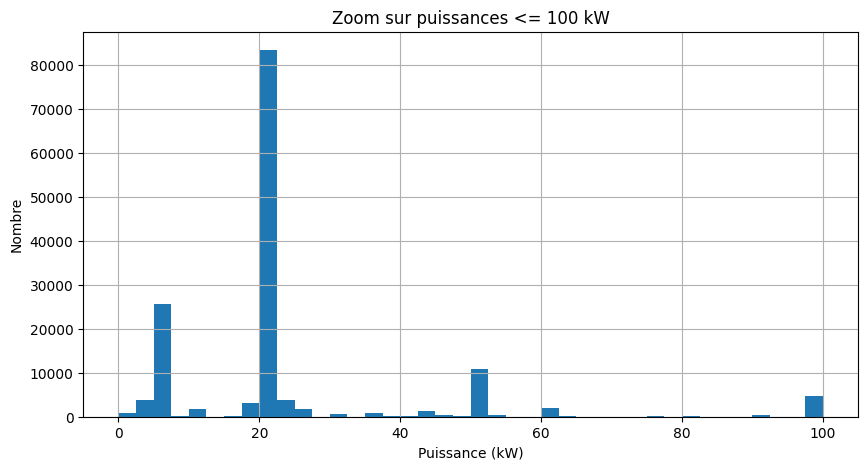

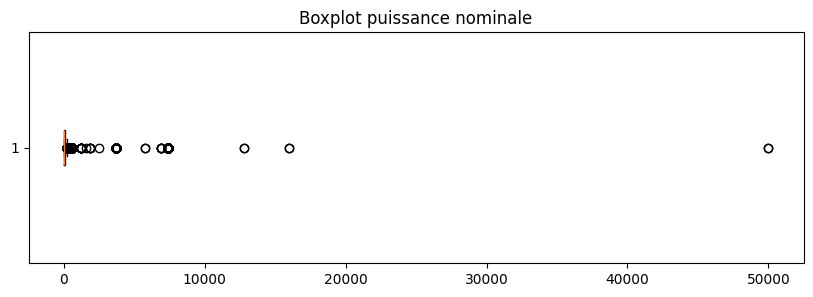

===== Quantiles =====
0.25     22.0
0.50     22.0
0.75    100.0
0.90    250.0
0.95    300.0
0.99    400.0
Name: puissance_nominale, dtype: float64

% bornes >= 7 kW : 97.46%
% bornes >= 22 kW : 81.51%
% bornes >= 43 kW : 34.54%
% bornes >= 50 kW : 33.64%
% bornes >= 100 kW : 26.30%
% bornes >= 150 kW : 21.37%


In [29]:
import matplotlib.pyplot as plt
# ----------------------------
# Statistiques générales
# ----------------------------
print("===== Statistiques =====")
print(df_filtre["puissance_nominale"].describe())
print()

# ----------------------------
# Valeurs les plus fréquentes
# ----------------------------
print("===== Top puissances =====")
print(df_filtre["puissance_nominale"].value_counts().head(10))
print()

# ----------------------------
# Zoom sur faibles puissances
# ----------------------------
plt.figure(figsize=(10,5))
df_filtre[df_filtre["puissance_nominale"] <= 100]["puissance_nominale"].hist(bins=40)
plt.title("Zoom sur puissances <= 100 kW")
plt.xlabel("Puissance (kW)")
plt.ylabel("Nombre")
plt.show()

# ----------------------------
# Boxplot
# ----------------------------
plt.figure(figsize=(10,3))
plt.boxplot(df_filtre["puissance_nominale"].dropna(), vert=False)
plt.title("Boxplot puissance nominale")
plt.show()

# ----------------------------
# Quantiles utiles
# ----------------------------
print("===== Quantiles =====")
print(df_filtre["puissance_nominale"].quantile([0.25,0.5,0.75,0.90,0.95,0.99]))
print()

# ----------------------------
# Parts selon seuils métier
# ----------------------------
for seuil in [7, 22, 43, 50, 100, 150]:
    pct = (df_filtre["puissance_nominale"] >= seuil).mean() * 100
    print(f"% bornes >= {seuil} kW : {pct:.2f}%")

La puissance nominale des bornes de recharge permet de caractériser leur vitesse de recharge. Dans un contexte IRVE, les valeurs observées doivent respecter des ordres de grandeur physiques et techniques connus.

#### Tranches de puissance attendues

On peut distinguer plusieurs catégories usuelles :

- **≤ 3 kW** : recharge très lente (cas rares, domestique ancien ou données erronées)
- **3 à 7 kW** : recharge lente (souvent domestique ou résidentielle)
- **7 à 22 kW** : recharge accélérée en courant alternatif (AC), très fréquente en voirie et parkings publics
- **22 à 50 kW** : recharge rapide (souvent en courant continu DC)
- **50 à 150 kW** : recharge rapide à très rapide (stations dédiées, axes routiers)
- **≥ 150 kW** : recharge ultra-rapide (autoroutes, hubs de recharge)

#### Valeurs aberrantes

Certaines valeurs ne sont pas cohérentes avec la réalité technique des infrastructures IRVE :

- **0 kW** : valeur invalide ou donnée manquante mal encodée
- **> 300–350 kW** : très rare et dépend de technologies spécifiques
- **50000 kW (ou valeurs extrêmes similaires)** : clairement aberrantes, probablement liées à une erreur de saisie ou d’unité (ex : W au lieu de kW)

Ces valeurs devraient être considérées comme des *outliers* et traitées (suppression ou correction) afin d’éviter tout biais dans les analyses.
Dans ce travail, ce traitement n’a pas été approfondi, mais il constitue une piste d’amélioration importante pour la robustesse des résultats.

### Définition d’une borne rapide

Dans le cadre de cette étude, nous considérons qu’une borne est dite **rapide** lorsque sa puissance est :

$$
\text{puissance nominale} \geq 43 \text{ kW}
$$
